<div style="border-bottom: 2px solid #e8a435; padding-bottom: 16px; margin-bottom: 24px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #e8a435; font-size: 13px; font-weight: 600; letter-spacing: 0.08em; text-transform: uppercase;">Jenner Analytics &nbsp;&bull;&nbsp; Customer Success Analytics</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #212121; font-size: 26px; font-weight: 700; margin-top: 6px;">Customer Churn Root Cause Analysis</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #757575; font-size: 14px; margin-top: 4px;">PROC FISHBONE cause-and-effect diagram for a mid-market B2B SaaS retention review</div>
</div>

## Executive Summary

This analysis organizes the root-cause drivers of elevated SaaS customer churn into a structured cause-and-effect (Ishikawa) diagram. The mid-market B2B segment is churning at roughly 18% annually against an 8% target. Twenty root-cause findings — drawn from exit surveys, customer success interviews, and cohort attribution — are grouped into six cause categories and rendered with `PROC FISHBONE` as a 27-node diagram (one effect, six category bones, twenty sub-causes).

The supporting `PROC MEANS` breakdown shows where attributable churn concentrates. **Product** carries the most findings (5 causes, 48.1 total impact points), followed by **Pricing** (4 causes, 42.3) and **Support** (4 causes, 40.2). Measured by average impact *per cause*, **Competition** is the most severe category (mean 11.8), and the single highest-impact finding overall is the **Pricing** renewal increase without prior warning (14.2). The `PROC SGPLOT` Pareto view ranks every individual cause so leadership can see which bones to act on first. The deliverable feeds the Customer Success quarterly retention review.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.CHURN_RCA | Customer churn root-cause findings consolidated from exit-survey analysis and the CS team retrospective; each row is one cause with its category, supporting evidence, and estimated churn-impact share | 20 |

---

In [1]:
/* --------------------------------------------------------
   Customer churn root-cause findings (RCA)
   SaaS platform, B2B mid-market segment.
   Each row: cause category, the specific cause, a
   supporting subcause/evidence note, and the estimated
   share of churn attributable to it (from exit-survey
   and cohort attribution).
   -------------------------------------------------------- */
data work.churn_rca;
    infile datalines dlm='|' dsd truncover;
    input category :$15. cause :$70. subcause :$90. churn_impact_pct;
    datalines;
Product|Core feature gaps vs enterprise competitors|Bulk export and API rate limits cited in 34% of exit surveys|12.4
Product|Reporting capabilities limited|No custom dashboard builder in standard tier|9.8
Product|Mobile app lags web functionality|3 key workflows mobile-only users cannot complete|8.2
Product|Frequent UI changes without notice|Power users disrupted by quarterly redesigns|7.6
Product|Integration marketplace gaps|Missing Salesforce and HubSpot native connectors|10.1
Pricing|Renewal price increase without prior warning|18% MRR increase with 30-day notice|14.2
Pricing|Per-seat model penalizes team growth|Cost doubles when team grows from 10 to 20|11.3
Pricing|Initial discount not renewable|Sticker shock at first renewal|9.7
Pricing|No multi-year contract incentive|Annual pricing identical to month-to-month|7.1
Support|First response time exceeds 24 hours|Tier benchmark is 4 hours|10.8
Support|Weekend support quality gap|Offshore coverage lacks product knowledge|9.3
Support|No dedicated CSM below Enterprise tier|Mid-market accounts have no named contact|11.5
Support|Escalation path unclear to customers|38% of churned accounts cited confusion on escalation|8.6
Onboarding|Time-to-value exceeds 90 days|Implementation complexity not disclosed pre-sale|12.9
Onboarding|Self-serve documentation outdated|Last updated 11 months ago|8.1
Onboarding|No in-app guided tours for new features|Feature adoption below 30% at 6 months|9.4
Competition|Competitor at 30% lower price|Three major accounts cited specific competitor|13.1
Competition|Competitor offers unlimited-seat pricing|Eliminates per-seat penalty for growing teams|10.6
Relationship|Executive sponsor turnover unmanaged|Champion left; no re-engagement program|11.7
Relationship|QBR cadence reduced to annual|CS team resource reduction 18 months ago|9.2
;
run;


NOTE: DATA work.churn_rca

NOTE: Processing inline DATALINES (20 lines)

NOTE: Read 20 rows from DATALINES.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: churn impact concentration by RCA category.
   Sum shows where attributable churn clusters; max flags
   the single worst cause in each category.
   -------------------------------------------------------- */
proc means data=work.churn_rca n sum mean max maxdec=1;
    class category;
    var churn_impact_pct;
    title 'Customer Churn RCA: Impact Percentage by Category';
run;


                                   Customer Churn RCA: Impact Percentage by Category                                    

                                                  The MEANS Procedure

                                          Analysis Variable : CHURN_IMPACT_PCT

        CATEGORY              N Obs            Sum           Mean        Maximum
        ------------------------------------------------------------------------
        Competition               2           23.7           11.8           13.1
        Onboarding                3           30.4           10.1           12.9
        Pricing                   4           42.3           10.6           14.2
        Product                   5           48.1            9.6           12.4
        Relationship              2           20.9           10.4           11.7
        Support                   4           40.2           10.1           11.5
        -----------------------------------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                   Customer Churn RCA: Impact Percentage by Category                                    



NOTE: PROC SORT data=work.churn_rca

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 20 rows from work.churn_rca.
NOTE: Wrote work.churn_rca (20 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=work.churn_rca

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


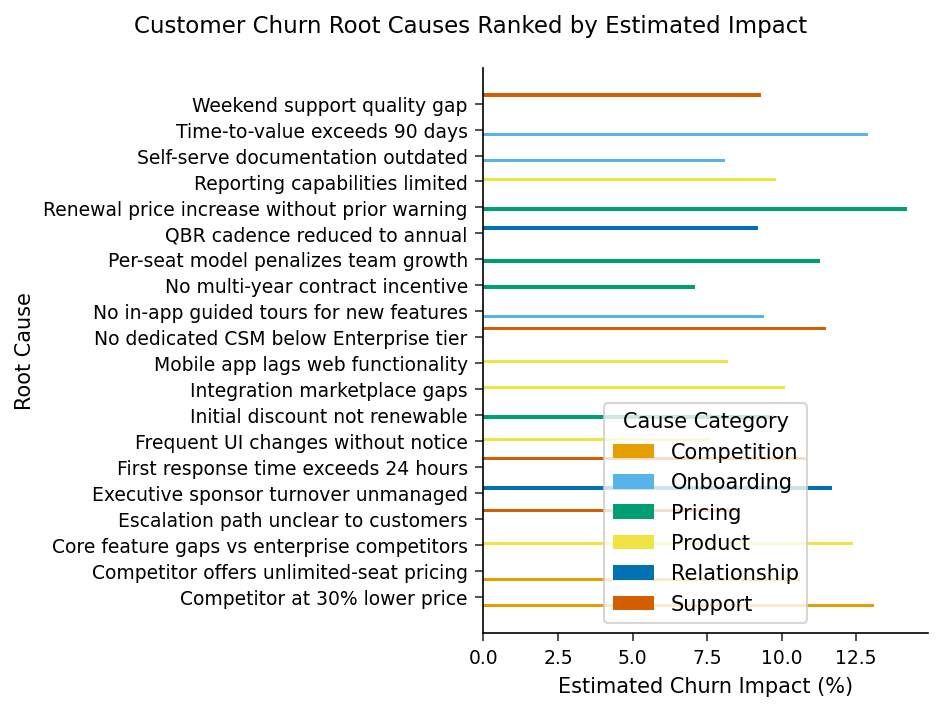

In [3]:
/* --------------------------------------------------------
   Pareto view: individual root causes ranked by estimated
   churn impact, colored by category. This complements the
   fishbone by quantifying which bones matter most.
   -------------------------------------------------------- */
proc sort data=work.churn_rca;
    by descending churn_impact_pct;
run;

proc sgplot data=work.churn_rca;
    hbar cause / response=churn_impact_pct
        group=category;
    xaxis label='Estimated Churn Impact (%)';
    yaxis label='Root Cause' discreteorder=data;
    keylegend / title='Cause Category' position=bottom;
    title 'Customer Churn Root Causes Ranked by Estimated Impact';
run;


---

### Cause-and-effect (Ishikawa) diagram

`PROC FISHBONE` builds the diagram directly from `WORK.CHURN_RCA`: each distinct `category` becomes a major bone off the central spine, and the individual `cause` findings hang from their category bone as sub-causes. The procedure prints the full cause-and-effect structure below — the effect at the head, the six category bones, and every sub-cause grouped under its bone — and writes the matching fishbone graphic to disk. The ranked Pareto chart above is the companion view that quantifies which of these bones carries the most attributable churn.

In [4]:
/* --------------------------------------------------------
   PROC FISHBONE: customer churn cause-and-effect diagram.
   The diagram is driven directly from WORK.CHURN_RCA, so
   the six cause categories and their causes are exactly
   the findings analyzed above. CATEGORY forms the major
   bones; CAUSE hangs as sub-causes off each bone.
   -------------------------------------------------------- */
proc fishbone data=work.churn_rca;
    cause category / subcause=cause;
    effect 'Elevated Customer Churn (18% annual vs 8% target)';
    title 'Customer Churn Root Cause Analysis - Mid-Market Segment';
    footnote 'Sources: exit surveys, CS team interviews, cohort attribution';
run;


                                   Customer Churn RCA: Impact Percentage by Category                                    


                    Customer Churn Root Cause Analysis - Mid-Market Segment
                    The FISHBONE Procedure

  Cause-and-Effect Diagram

  [EFFECT] Elevated Customer Churn (18% annual vs 8% target)
    [CAUSE] Pricing (top)
      [SUB] Renewal price increase without prior warning
      [SUB] Per-seat model penalizes team growth
      [SUB] Initial discount not renewable
      [SUB] No multi-year contract incentive
    [CAUSE] Competition (top)
      [SUB] Competitor at 30% lower price
      [SUB] Competitor offers unlimited-seat pricing
    [CAUSE] Onboarding (top)
      [SUB] Time-to-value exceeds 90 days
      [SUB] No in-app guided tours for new features
      [SUB] Self-serve documentation outdated
    [CAUSE] Product (bottom)
      [SUB] Core feature gaps vs enterprise competitors
      [SUB] Integration marketplace gaps
      [SUB] Reporting capabi

NOTE: PROC FISHBONE
NOTE: PROC FISHBONE: wrote SVG to ./actual/fishbone.svg
NOTE: Output dataset has 27 nodes


---

### Interpretation

The cause-and-effect structure and the per-category `PROC MEANS` figures point leadership to a small number of high-leverage moves. The two highest single-cause findings — the **Pricing** renewal increase without warning (14.2) and the **Competition** finding that a rival sells equivalent capability at 30% lower price (13.1) — are both commercial rather than product issues, suggesting that pricing transparency and competitive positioning are the most pressing near-term levers. **Onboarding** time-to-value exceeding 90 days (12.9) is the largest service-side finding and ties directly to pre-sale expectation setting.

By volume, **Product** dominates the diagram (5 of 20 findings, 48.1 total impact points), but its findings are individually smaller (mean 9.6) than those in **Competition** (mean 11.8) or **Pricing** (mean 10.6) — a reminder that a long list of product gaps is not automatically the top priority. The **Relationship** bone (executive-sponsor turnover and reduced QBR cadence, 20.9 combined) represents process changes the CS team can implement within the current quarter without product or pricing investment, offering the fastest path to measurable retention improvement. The full ranked list in the Pareto chart lets the leadership team sequence interventions by estimated impact rather than by category size.

---

In [5]:
/* --------------------------------------------------------
   Export churn RCA findings for strategy review deck
   -------------------------------------------------------- */
proc export data=work.churn_rca
    outfile='customer_churn_rca_findings.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.churn_rca outfile=customer_churn_rca_findings.csv

NOTE: Exported 20 rows to customer_churn_rca_findings.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>